# Prediction of stress at a Distance x from the center Using Random Forest

In [27]:
import pandas as pd
import numpy as np
import os

In [28]:
mean_square_error = []
def get_image_input(sim_no,output,r,path):
    import pandas as pd
    import numpy as np
    import os
    sim = 998
    nodes = 9271
    #path = 'csv_files/sim_w_comb_'
    file = path + f'{sim_no}/S_U_PEEQ_COORD_{sim_no}.csv'
    if os.path.isfile(file):
       
        df = pd.read_csv(file)
        df = df.replace('       NoValue', np.nan)
        df.columns = df.columns.str.lstrip()
        x_cord = df['X']
        y_cord = df['Y']
        rho = np.zeros(len(y_cord))
        phi = np.zeros(len(y_cord))
        for i in range((len(x_cord))):
            rho[i] = np.sqrt(x_cord[i]**2 + y_cord[i]**2)
            phi[i] = np.arctan2(y_cord[i], x_cord[i])
        df['R'] = rho
        df['theta'] = phi
        df_data = df[(df['R'] > r-5) & (df['R'] < r+5)]
        df_data = df_data.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
        data_S11 = df_data['S-S11'].values
        data_S22 = df_data['S-S22'].values
        data_S33 = df_data['S-S33'].values
        data_S12 = df_data['S-S12'].values
        data_X = df_data['X'].values
        data_Y = df_data['Y'].values
        data_r = df_data['R'].values
        data_theta = df_data['theta'].values
        if output == 'sigmax':
            return (data_S11)
        if output == 'sigmay':
            return (data_S12)
        if output == 'sigmaz':
            return (data_S33)
        if output == 'r':
            return(data_r)
        if output == 'theta':
            return(data_theta)
        if output == 'x':
            return(data_X)
        if output == 'y':
            return(data_Y)

            
        

### Getting X input

In [4]:
# Setting up input for the model
def get_xinput(r,len1):
    import numpy as np
    a = np.zeros((len1,sim_count))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r, 'csv_files/sim_w_comb_')
    return a



### Getting Y output

In [29]:
# Setting up y-output
def get_youtput(r,len2):
    import numpy as np
    a = np.zeros((len2,sim_count))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r, 'csv_files/sim_w_comb_')
    return a


51

# Implementing ML model (Random Forest)

### Data Preparation

In [136]:
# r is the the radius of the cavity, x is the distance from the center of the cavity
ro = 500
x = 2400 
# len1, len2 is used to evaluate the no. of nodes or discretization
len1 = len(get_image_input(1,'sigmax',ro, path = 'csv_files/sim_w_comb_'))
len2 = len(get_image_input(1,'sigmax',x, path = 'csv_files/sim_w_comb_'))
temp_in= []
temp_ex = []
for i in range(1000):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)
sim_count = len(temp_in)
x_input = get_xinput(r,len1)
y_output = get_youtput(x,len2)
x_input = x_input.reshape(sim_count,len1)
y_output = y_output.reshape(sim_count,len2)

In [137]:
# Cases used for prediction
case = [16,134,198,312,401,632,708,795,866,987]
sigma_x = np.zeros((len2,len(case)))
x1 = np.zeros((len2,len(case)))
y1 = np.zeros((len2,len(case)))
theta = np.zeros((len1,len(case)))
for i in range(len(case)):
    sigma_x[:,i] = get_image_input(case[i],'sigmax',x,'csv_files1/sim_w_comb_' )
    x1[:,i] = get_image_input(case[i],'x',x, 'csv_files1/sim_w_comb_')
    y1[:,i] = get_image_input(case[i],'y',x, 'csv_files1/sim_w_comb_')
    theta[:,i] = get_image_input(case[i],'theta',r, 'csv_files1/sim_w_comb_')

In [138]:
# Spliting testing and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_input, y_output, test_size=0.2, random_state = 42)

### Hyperparameter tuning

In [139]:
par_grid  = [{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [2, 5, 10, 20, 50]}]

In [140]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor()
from sklearn.model_selection import GridSearchCV
tune_randomforest = GridSearchCV(regressor, param_grid = par_grid ,cv = 5, verbose = True, n_jobs = -1)
tune_randomforest.fit(x_train,y_train)
# The best output parameters for model
tune_randomforest.best_params_

Fitting 5 folds for each of 1980 candidates, totalling 9900 fits


{'bootstrap': True,
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 50}

In [141]:
rf_regressor = RandomForestRegressor(bootstrap= True,
 max_depth= 10,
 max_features= 'sqrt',
 min_samples_leaf= 4,
 min_samples_split= 2,
 n_estimators= 50)
rf_regressor.fit(x_train, y_train)


RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=4,
                      n_estimators=50)

In [142]:
theta = theta.reshape(len(case),len1)

In [143]:
prediction = rf_regressor.predict(theta)

In [144]:
# Evaluating the metric score
from sklearn import metrics
sigma_x = sigma_x.reshape(len(case),len2)
x1 = x1.reshape(len(case),len2)
y1 = y1.reshape(len(case),len2)
mse = metrics.mean_squared_error(sigma_x, prediction)
mean_square_error.append(mse)

In [145]:
x = np.asarray(x1[5,:])
y = np.asarray(y1[5,:])
z1 = np.asarray(prediction[5])
z_ml = z1.copy()
z2 = np.asarray(sigma_x[5,:])
z_sim = z2.copy()

In [179]:
df_sim_500 = pd.DataFrame({'x': get_image_input(case[5],'x',500, 'csv_files1/sim_w_comb_'), "y":get_image_input(case[5],'y',500, 'csv_files1/sim_w_comb_') , "sigmax_randomforest":get_image_input(case[5],'sigmax',500, 'csv_files1/sim_w_comb_') ,"sigmax_sim":get_image_input(case[5],'sigmax',500, 'csv_files1/sim_w_comb_')})

In [40]:

df_sim_600 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [51]:
df_sim_800 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [62]:
df_sim_1000 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [73]:
df_sim_1200 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [85]:
df_sim_1400 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [97]:
df_sim_1600 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [109]:
df_sim_1800 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [123]:
df_sim_2000 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [134]:
df_sim_2200 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [146]:
df_sim_2400 = pd.DataFrame({'x': x, "y":y , "sigmax_randomforest":z_ml ,"sigmax_sim":z_sim})

In [148]:
mean_square_error

[0.00028662838861999104,
 0.00030555378528170215,
 0.00035694551006062666,
 0.00037705578297471035,
 0.0005196690780344059,
 0.0004173388062552864,
 0.0005724773965937259,
 0.00031523470968109645,
 0.0005324405284694631,
 0.0004502952411098117]

In [180]:
data =[]

In [181]:

data.append(df_sim_600)
data.append(df_sim_800)
data.append(df_sim_1000)
data.append(df_sim_1200)
data.append(df_sim_1400)
data.append(df_sim_1600)
data.append(df_sim_1800)
data.append(df_sim_2000)
data.append(df_sim_2200)
data.append(df_sim_2400)
data.append(df_sim_500)

In [182]:
final_df = pd.concat(data)

In [183]:
final_df

,x,y,sigmax_randomforest,sigmax_sim
0,73.7468,592.7550,-0.039862,-0.048903
1,73.7468,592.7550,-0.038253,-0.069436
2,73.7468,592.7550,-0.035409,-0.040916
3,73.7468,592.7550,-0.037521,-0.054216
4,73.7468,592.7550,-0.039450,-0.049953
...,...,...,...,...
123,485.0160,-121.4900,-0.010139,-0.010139
124,490.3930,-97.5452,-0.008696,-0.008696
125,494.5880,-73.3652,-0.006913,-0.006913
126,497.5920,-49.0086,-0.005996,-0.005996


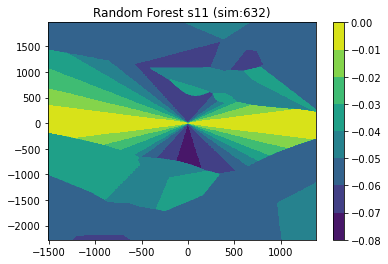

In [196]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = final_df['x']
y = final_df['y']
z = final_df["sigmax_randomforest"]
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Random Forest s11 (sim:632)")
plt.colorbar()

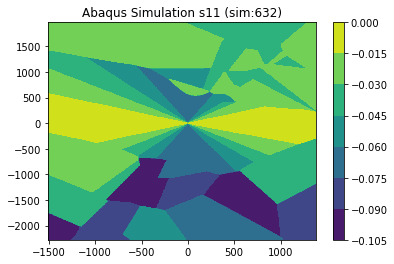

In [197]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = final_df['x']
y = final_df['y']
z = final_df["sigmax_sim"]
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()